In [215]:
import numpy as np;
from matplotlib import pyplot as plt
import scipy.integrate as integrate

# Exercise 08: Variational Monte Carlo and Simulated Annealing

## The Physical Problem
The goal of this exercise is to find the ground state energy and the corresponding probability density of a single quantum particle in a 1D double-well potential:
$$V(x) = x^4 - \frac{5}{2}x^2$$

Since this potential cannot be solved exactly analytically, we rely on the **Variational Principle**. This principle states that the expectation value of the Hamiltonian $\langle \hat{H} \rangle$ evaluated for any trial wave function $\Psi_T(x)$ is a rigorous upper bound to the true ground state energy $E_0$:
$$E_T = \frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}{\int dx |\Psi_T(x)|^2} \ge E_0$$

We propose a trial wave function modeled as the superposition of two Gaussians, introducing two variational parameters, $\mu$ (mean) and $\sigma$ (standard deviation):
$$\Psi_T^{\mu, \sigma}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$$

The objective is to compute the integral $E_T$ and find the optimal set of parameters $(\mu, \sigma)$ that minimizes it.

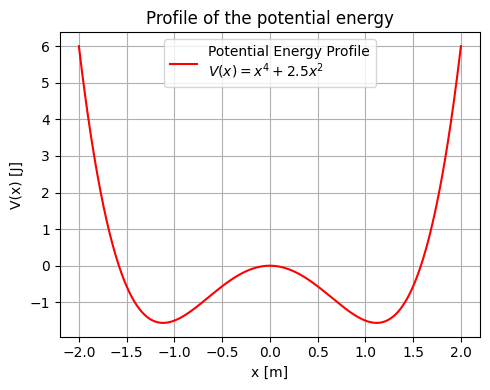

In [200]:
def Vpot(x):
    return (x**2 - 2.5) * x**2

# Plot potential
x = np.linspace(-2, 2, 500)
V = Vpot(x)

plt.figure(figsize=(5, 4))
plt.plot(x, V, c='r', label='Potential Energy Profile\n$V(x) = x^4 + 2.5x^2$')
plt.xlabel('x [m]')
plt.ylabel('V(x) [J]')
plt.title('Profile of the potential energy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Since this potential cannot be solved exactly analytically, we rely on the **Variational Principle**. This principle states that the expectation value of the Hamiltonian $\langle \hat{H} \rangle$ evaluated for a trial wave function $\Psi_T(x)$ (that has the minimum regularity requirements: it is differentiatable and normalizable) is a rigorous upper bound to the true ground state energy $E_0$:
$$E_T = \frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}{\int dx |\Psi_T(x)|^2} \ge E_0$$

We propose a trial wave function modeled as the superposition of two Gaussians, introducing two variational parameters, $\mu$ (mean) and $\sigma$ (standard deviation):
$$\Psi_T^{\mu, \sigma}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$$

The objective is to compute the integral $E_T$ and find the optimal set of parameters $(\mu, \sigma)$ that minimizes it.

## Computational Architecture

Our solution is divided into two distinct computational phases, implemented in C++: the first is the **Optimization Phase** and the second is the **Production Phase**, which uses the results from the Optimization Phase.

These tasks require the calculation of the square modulus of the wavefunction and its second derivative for the calculation of the kinetic energy.

### 1. Calculation of $|\Psi_T|^2$ for Metropolis Sampling
The trial wave function is a symmetric superposition of two Gaussians:
$$\Psi_T^{\mu, \sigma}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$$

For the Metropolis algorithm, we need to sample the probability density $|\Psi_T|^2$. Since the Metropolis acceptance ratio only depends on the relative probabilities, we can drop all normalization factors that do not depend on the position $x$:

$$
\begin{aligned}
|\Psi_T^{\mu, \sigma}(x)|^2 &\propto \left( e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}} \right)^2 \\
&= e^{-\frac{(x-\mu)^2}{\sigma^2}} + e^{-\frac{(x+\mu)^2}{\sigma^2}} + 2e^{-\frac{x^2+\mu^2}{\sigma^2}} \\
&= e^{-\frac{x^2+\mu^2}{\sigma^2}}\left[e^{\frac{2x\mu}{\sigma^2}} + e^{-\frac{2x\mu}{\sigma^2}} + 2\right] \\
&\propto e^{-\frac{x^2}{\sigma^2}} \cosh^2\left(\frac{x\mu}{\sigma^2}\right)
\end{aligned}
$$

This compact form is computationally efficient and prevents numerical overflow/underflow during the simulation.

### 2. Analytical Calculation of the Local Energy
To compute the expectation value of the Hamiltonian $\langle \hat{H} \rangle_T$, we evaluate the local energy $E_{loc}(x)$ at each sampled configuration, where $E_{loc}(x)$ is

$$E_{loc}(x) = \frac{\hat{H} \Psi_T(x)}{\Psi_T(x)}$$

 Setting $\hbar = 1$ and $m = 1$, the kinetic part of the local energy is given by:
$$K_{loc}(x) = \frac{-\frac{1}{2}\frac{\partial^2}{\partial x^2} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}$$

First, we compute the first derivative:
$$\frac{\partial}{\partial x} \Psi^{\mu, \sigma}_T(x) = -\frac{1}{\sigma^2}\left[(x-\mu)e^{-\frac{(x-\mu)^2}{2\sigma^2}} + (x+\mu)e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right]$$

Next, we evaluate the second derivative:
$$
\begin{aligned}
\frac{\partial^2}{\partial x^2} \Psi^{\mu, \sigma}_T(x) &= -\frac{1}{\sigma^2}\left[e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right] + \frac{1}{\sigma^4}\left[(x-\mu)^2e^{-\frac{(x-\mu)^2}{2\sigma^2}} + (x+\mu)^2e^{-\frac{(x+\mu)^2}{2\sigma^2}}\right] \\
&= -\frac{1}{\sigma^2}\Psi^{\mu, \sigma}_T(x) + \frac{x^2 + \mu^2}{\sigma^4}\Psi^{\mu, \sigma}_T(x) + \frac{2x\mu}{\sigma^4}\left[e^{-\frac{(x+\mu)^2}{2\sigma^2}} - e^{-\frac{(x-\mu)^2}{2\sigma^2}}\right] \\
&= -\frac{1}{\sigma^2}\Psi^{\mu, \sigma}_T(x) + \frac{x^2 + \mu^2}{\sigma^4}\Psi^{\mu, \sigma}_T(x) + \frac{2x\mu}{\sigma^4}e^{-\frac{x^2+\mu^2}{2\sigma^2}}\left[e^{-\frac{x\mu}{\sigma^2}} - e^{\frac{x\mu}{\sigma^2}}\right]
\end{aligned}
$$

Dividing by the wave function $\Psi_T(x) = e^{-\frac{x^2+\mu^2}{2\sigma^2}}\left[e^{\frac{x\mu}{\sigma^2}} + e^{-\frac{x\mu}{\sigma^2}}\right]$ yields the hyperbolic tangent:
$$\frac{\frac{\partial^2}{\partial x^2} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} = -\frac{1}{\sigma^2} + \frac{x^2 + \mu^2}{\sigma^4} - \frac{2x\mu}{\sigma^4} \tanh\left(\frac{x\mu}{\sigma^2}\right)$$

Finally, multiplying by $-\frac{1}{2}$, we obtain the analytical expression implemented in the C++ code:
$$K_{loc}(x) = \frac{1}{2\sigma^2} - \frac{x^2 + \mu^2}{2\sigma^4} + \frac{x\mu}{\sigma^4} \tanh\left(\frac{x\mu}{\sigma^2}\right)$$

In [201]:
SA_step, temperature, energy, energy_error = np.loadtxt("outputs/energy.dat", unpack=True)
SA_step, temperature, mu, sigma = np.loadtxt("outputs/mu_sigma.dat", unpack=True)

### Phase 1: Optimization (Simulated Annealing)
To minimize the multidimensional integral $E_T$, we treat it as a cost function and explore the $(\mu, \sigma)$ parameter space using a **Simulated Annealing (SA)** algorithm. 

The optimization follows these steps:
* A fictitious temperature $T$ is introduced.
* At each step, we propose a random shift in the parameters $\mu$ and $\sigma$.
* The energy of the new configuration is evaluated using a short **Variational Monte Carlo (VMC)** run (Metropolis algorithm sampling $|\Psi_T(x)|^2$).
* Moves that lower the energy are always accepted. Uphill moves are accepted with a probability $p = e^{-\Delta E / T}$.

**The Cooling Schedule**
To efficiently find the global minimum, the temperature is decreased using a **geometric cooling** law: 
$$T_{i+1} = \alpha T_i$$ 
where $\alpha$ is a constant strictly less than 1 (e.g., $0.995$). This multiplicative update dynamically adjusts the step size, naturally balancing two distinct phases:
* **Fast Exploration (High $T$):** When the temperature is high, the absolute temperature drops ($\Delta T$) are large. The system quickly traverses this regime, freely jumping out of local minima without wasting computational time.
* **Fine-Tuning (Low $T$):** As $T$ approaches zero, the temperature steps become microscopic. The cooling slows down drastically, allowing the system to spend the vast majority of its steps meticulously fine-tuning the parameters near the global minimum to pinpoint the exact best configuration.

The plot below shows the temperature values as functions of the SA step.

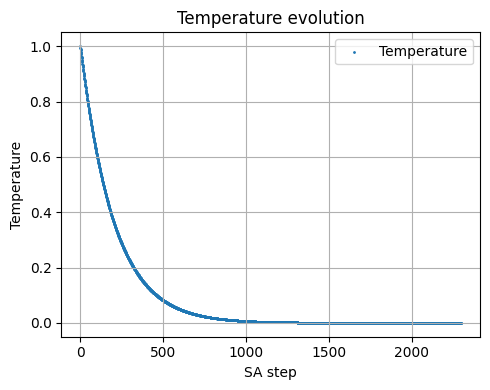

In [214]:
plt.figure(figsize=(5, 4))
plt.scatter(SA_step, temperature, marker='o', s=1, label="Temperature")
plt.xlabel("SA step")
plt.ylabel("Temperature")
plt.title("Temperature evolution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Dynamic Precision: Balancing Speed and Accuracy
During the Simulated Annealing optimization, the evaluation of the energy difference $\Delta E$ between two parameter configurations is subject to statistical noise. The impact of this noise on the Metropolis acceptance probability ($p = e^{-\Delta E / T}$) changes drastically with temperature:

* **High Temperatures (Fast Exploration):** The acceptance probability is high even for uphill moves. The large thermal noise $T$ effectively "masks" the statistical error on $\Delta E$. Therefore, we can safely compute the energy using a smaller number of blocks. This sacrifices a bit of unnecessary precision to drastically speed up the initial exploration of the parameter space.
* **Low Temperatures (Fine-Tuning):** As $T \to 0$, the algorithm becomes extremely selective. A small statistical error on $\Delta E$ can lead to a completely wrong acceptance probability, potentially causing the algorithm to reject a move towards the true ground state. In this regime, maximum precision is required. By dynamically increasing the number of blocks as the temperature drops, we progressively reduce the statistical uncertainty (which scales as $1/\sqrt{N_{blocks}-1}$). This provides the algorithm with a clear, reliable energy signal to pinpoint the exact global minimum.

*Note: While the number of blocks can be dynamic, the `BLOCK_LENGTH` must remain fixed and sufficiently long throughout the entire simulation to guarantee the statistical independence of the VMC measurements and overcome the spatial autocorrelation time.*

The plots below visualize this search process, showing the energy converging as the temperature drops and the trajectory of the random walker in the parameter space.

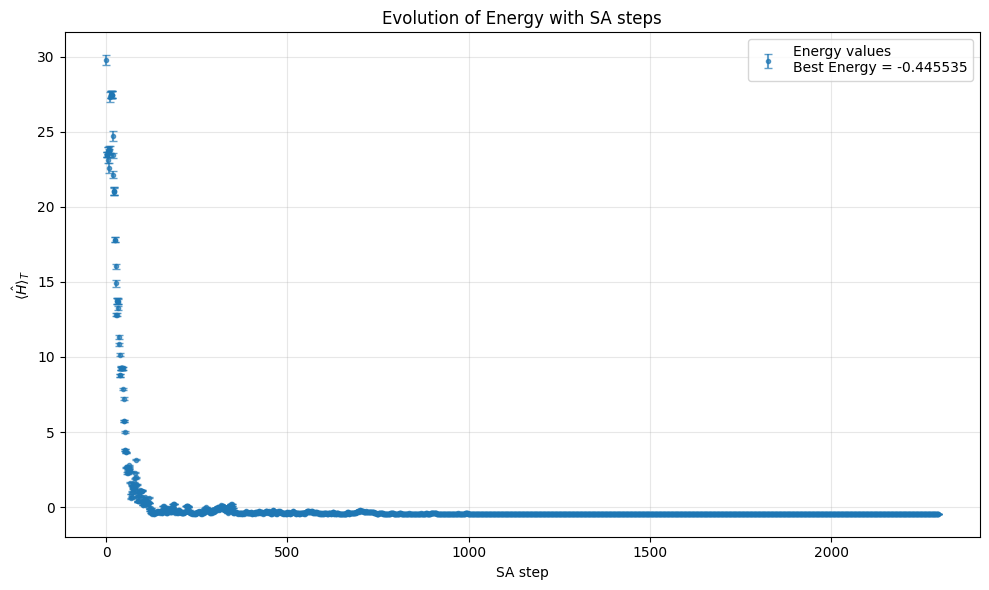

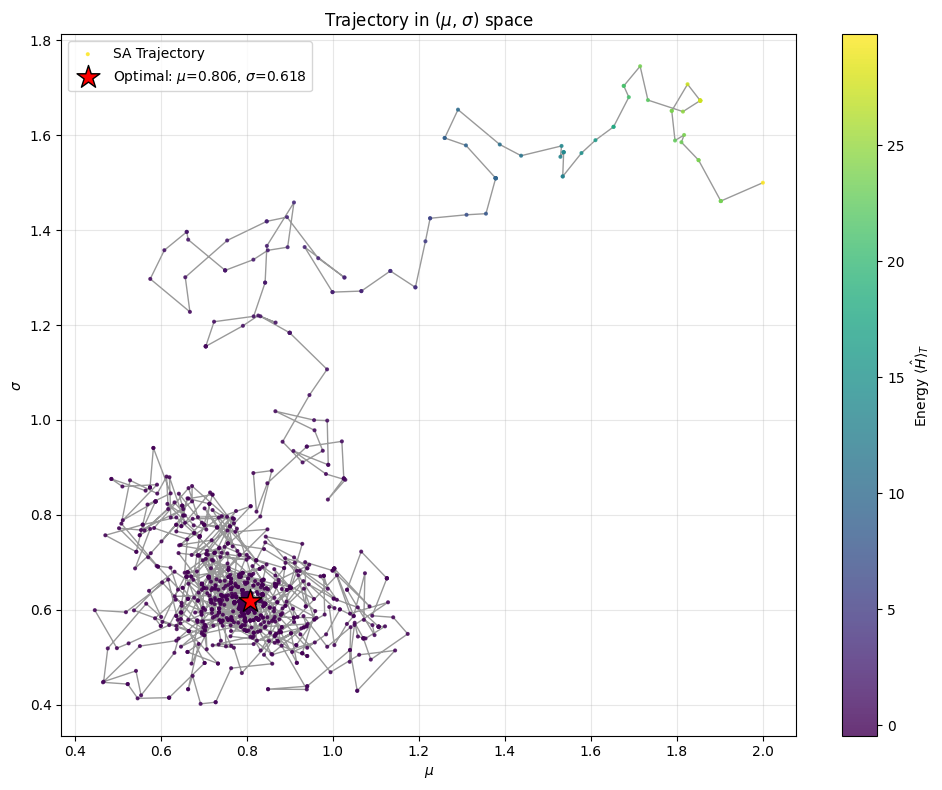

In [203]:
# =========================================================
# FIGURE 1: Energy Evolution
# =========================================================

plt.figure(figsize=(10, 6))

plt.errorbar(SA_step, energy, yerr=energy_error, fmt='.', label=f'Energy values\nBest Energy = {np.min(energy)}', capsize=3, alpha=0.7)
plt.title('Evolution of Energy with SA steps')
plt.ylabel(r'$\langle {\hat H} \rangle_T$')
plt.xlabel('SA step')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# FIGURE 2: Trajectory in Parameter Space
# =========================================================
plt.figure(figsize=(10, 8))

plt.plot(mu, sigma, color='gray', alpha=0.8, linewidth=1.0, zorder=1)
sc = plt.scatter(mu, sigma, marker='.', c=energy, cmap='viridis', alpha=0.8, s=15, zorder=2, label='SA Trajectory')
cbar = plt.colorbar(sc)
cbar.set_label(r'Energy $\langle {\hat H} \rangle_T$')

# Optimal values
best_idx = np.argmin(energy)
best_mu = mu[best_idx]
best_sigma = sigma[best_idx]

plt.scatter(best_mu, best_sigma, marker='*', color='red', edgecolor='black', s=300, zorder=5, 
            label=f'Optimal: $\mu$={best_mu:.3f}, $\sigma$={best_sigma:.3f}')

plt.title("Trajectory in ($\mu$, $\sigma$) space")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### Simulation Configuration and Parameter Tuning
To execute the optimization and achieve these results, the system reads its execution parameters from an external `inputs/config.dat` file. This allows for quick tuning without recompiling the C++ code. The parameters used for the Simulated Annealing (SA) run are shown below:

```text
HIGH_BLOCKS 10
LOW_BLOCKS 40 
BLOCK_LENGTH 20000
N_EQUILIBRATION_STEPS 10000
MU_STEP 0.1
SIGMA_STEP 0.1
TEMPERATURE 1.0
TEMP_REDUCTION_FACTOR 0.995
TMIN 0.00001
INITIAL_MU 2.0
INITIAL_SIGMA 1.5
```
*(Note: Production run parameters are omitted here as they will be discussed in the final measurement section).*

These parameters govern different physical and computational aspects of the algorithm:

**1. Dynamic Precision (Data Blocking)**
* **`HIGH_BLOCKS` (10) & `LOW_BLOCKS` (40):** These dictate the dynamic number of blocks used to evaluate the Hamiltonian expectation value $\langle {\hat H} \rangle_T$. At high temperatures, thermal noise dominates, so we save computational time by using only 10 blocks. As the system cools, the precision automatically scales up to 40 blocks to accurately resolve the small energy differences needed to pinpoint the global minimum.
* **`BLOCK_LENGTH` (20000):** Kept fixed and sufficiently large to defeat the spatial autocorrelation of the Metropolis walker during the VMC integration.
* **`N_EQUILIBRATION_STEPS` (10000):** The number of steps the Metropolis walker performs before any energy measurements are taken, ensuring the system is fully thermalized and sampling the correct $|\Psi_T(x)|^2$ distribution.

**2. The Cooling Schedule**
* **`TEMPERATURE` (1.0) & `TMIN` (0.00001):** The starting and stopping fictitious temperatures for the SA algorithm.
* **`TEMP_REDUCTION_FACTOR` ($\alpha = 0.995$):** The multiplier for the geometric cooling law ($T_{i+1} = \alpha T_i$). A value of $0.995$ is highly conservative, guaranteeing a slow, meticulous descent into the global minimum. However, experimental tuning shows that values like $\alpha = 0.99$ or even $\alpha = 0.95$ can yield equivalently excellent results while drastically reducing the total execution time.

**3. Parameter Space Exploration**
* **`INITIAL_MU` (2.0) & `INITIAL_SIGMA` (1.5):**  The starting guess for the variational parameters. Usually, one would start with a "reasonable" physical guess (like $\mu=0.0$, $\sigma=1.0$, as I initially did). However, I deliberately chose to start from a point very far away from the expected ground state ($\mu=2.0$, $\sigma=1.5$). This choice makes the descent process highly visible in the plots and proves the algorithm's ability to avoid local minima and converge correctly regardless of the starting conditions (the results obtaained with this initial choice are basically identical to the ones obtained starting from the "resonable" point).
* **`MU_STEP` (0.1) & `SIGMA_STEP` (0.1):** The maximum amplitude of the uniform random displacement proposed by the SA algorithm to update the configuration at each temperature step.

To compile and run the optimization file, run

```bash
make run_opt
```
while in the `Lab08/` directory.

### Phase 2: The Production Run
During Simulated Annealing, the probability distribution is a "moving target" because $\mu$ and $\sigma$ are constantly changing. Therefore, the statistical uncertainties evaluated during the search are not definitive. 

Once the SA algorithm completes and identifies the absolute optimal parameters ($\mu_{best}$ and $\sigma_{best}$), we freeze the wave function. We then perform a final **Production Run**, that is a high-statistics Variational Monte Carlo simulation. 

Using the **Data Blocking** method, we rigorously evaluate the final expectation value of the Hamiltonian $\langle {\hat H} \rangle _T$ and its statistical uncertainty.

For this final measurement, the `production.cpp` code reads the configuration parameters directly from the `inputs/config.dat` file, specifically utilizing the `N_EQUILIBRATION_STEPS`, `PROD_BLOCKS`, and `PROD_BLOCK_LENGTH` fields.

To compile and execute this production phase, run the following command from the `Lab08/` directory:

```bash
make run_prod
```

In [204]:
blk, energy_prod, error_prod = np.loadtxt("outputs/best_energy_blocks.dat", unpack=True)

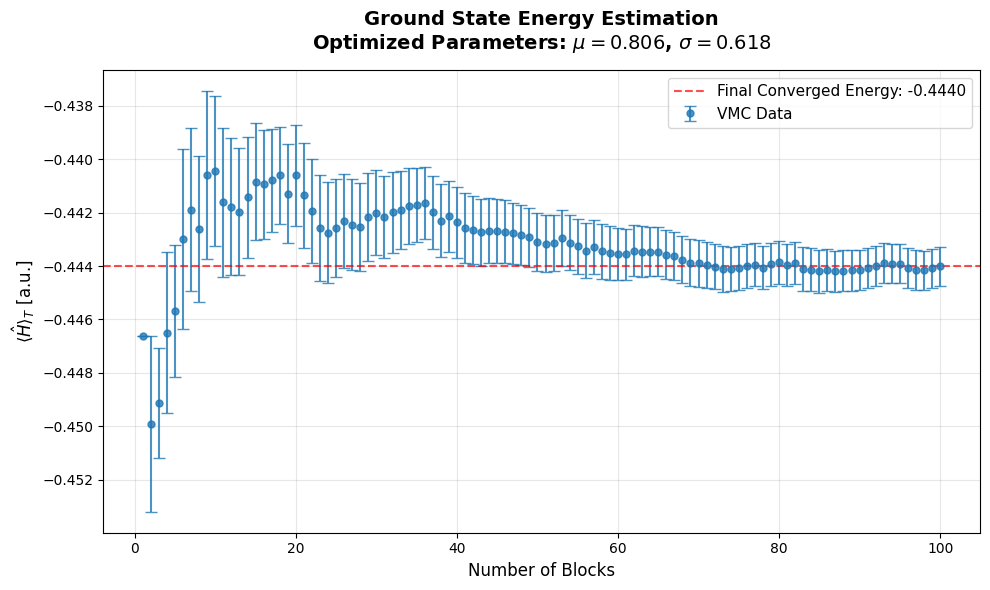

In [205]:
# =========================================================
# FIGURE 1: Energy vs. Block
# =========================================================
plt.figure(figsize=(10, 6))

plt.errorbar(x=blk, y=energy_prod, yerr=error_prod, fmt='o', elinewidth=1.5, capsize=4, markersize=5, 
             alpha=0.8, label=r'VMC Data')

# Horizontal line showing the final converged energy
final_energy = energy_prod[-1]
plt.axhline(y=final_energy, color='red', linestyle='--', alpha=0.7, 
            label=f'Final Converged Energy: {final_energy:.4f}')

plt.xlabel("Number of Blocks", fontsize=12)
plt.ylabel(r"$\langle {\hat H} \rangle_T$ [a.u.]", fontsize=12)
plt.title(f"Ground State Energy Estimation\n"
          f"Optimized Parameters: $\mu={best_mu:.3f}$, $\sigma={best_sigma:.3f}$", 
          fontsize=14, fontweight='bold', pad=15)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ground State Probability Density
As a final validation of our computational pipeline, we extract the spatial configurations (the $x$ coordinates) visited by our Metropolis random walker during the production run. We use this to build a histogram representing the sampled probability density.

To prove the accuracy of our Variational Monte Carlo, we compare this histogram against two rigorous baselines:
1. **The Analytic Curve:** The mathematical formula of $|\Psi_T^{\mu, \sigma}(x)|^2$ evaluated with our optimal parameters.
2. **The True Ground State (Matrix Equation):** We transform the continuous time-independent Schrödinger equation into a discrete eigenvalue problem using the **Finite Differences** method. By diagonalizing the resulting Hamiltonian matrix, we obtain the exact numerical ground state energy and wave function.

The plot below superimposes our VMC sampling, our analytical approximation, and the true numerical ground state. The slight mismatch between our optimized trial wave function and the exact matrix solution visually demonstrates the fundamental limitation of the chosen functional form (the two Gaussians) and perfectly illustrates the Variational Principle in action: the energy found with the Variational Montecarlo is slightly higher than the *true* ground state energy found with the numerical method. The fact is expected, since the VMC provides an upper limit for the ground state energy.

In [210]:
# Analytical curve
def psi_T_sq(x_val, mu, sigma):
    term1 = np.exp(-(x_val - mu)**2 / (2 * sigma**2))
    term2 = np.exp(-(x_val + mu)**2 / (2 * sigma**2))
    return (term1 + term2)**2
norm, _ = integrate.quad(psi_T_sq, -10, 10, args=(best_mu, best_sigma))

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations for matrix form of Schroedinger equation

In [211]:
x_sampled = np.loadtxt("outputs/sampled_x.dat")
x_analytic = np.linspace(-a/2, a/2, N)
x_matrix = np.linspace(-a/2, a/2, N)

In [212]:
# Find analytical numerical solution to Schroedinger equation
dx = x_matrix[1] - x_matrix[0] # the step size
V = Vpot(x_matrix)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E, psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

psi_ground_sq = (psi[0])**2

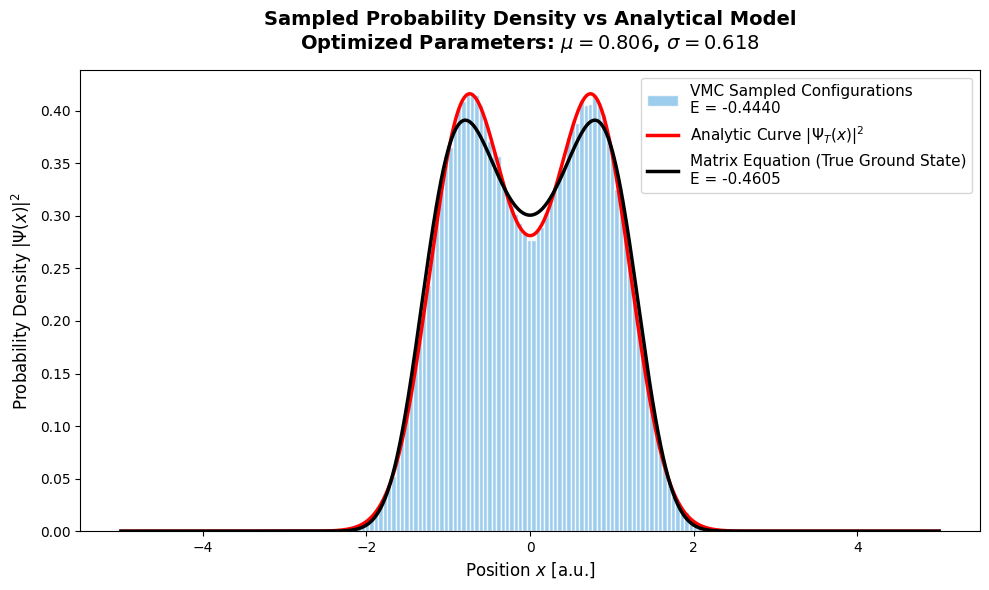

In [222]:
# Sampled Wavefunction vs Analytical vs Numerical

plt.figure(figsize=(10, 6))

# Simulation histogram
plt.hist(x=x_sampled, bins=100, density=True, color='#85C1E9', edgecolor='white', 
         alpha=0.8, label=f'VMC Sampled Configurations\nE = {final_energy:.4f}')

# Analytical curve
# Normalize first
y_analytic = psi_T_sq(x_analytic, best_mu, best_sigma) / norm
plt.plot(x_analytic, y_analytic, color='red', linewidth=2.5, 
         label=r'Analytic Curve $|\Psi_T(x)|^2$')

# Matrix Numerical Solution
plt.plot(x_matrix, psi_ground_sq, color='black', linewidth=2.5, 
         label=f'Matrix Equation (True Ground State)\nE = {E[0]:.4f}')



plt.xlabel("Position $x$ [a.u.]", fontsize=12)
plt.ylabel(r"Probability Density $|\Psi(x)|^2$", fontsize=12)
plt.title(f"Sampled Probability Density vs Analytical Model\n"
          f"Optimized Parameters: $\mu={best_mu:.3f}$, $\sigma={best_sigma:.3f}$", 
          fontsize=14, fontweight='bold', pad=15)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()